<a href="https://colab.research.google.com/github/lucasmsorrentino/FrameworksAI/blob/main/2_Trabalho_final_Regressao_(RNA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IAA012 - Frameworks de IA - Trabalho Final
## Integrantes: Lucas de Castro Oliveira e Lucas Martins Sorrentino

## 2. Resolução de exercício de RNA - Regressão
---

#### 1. Importação das bibliotecas

In [29]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.python.keras import backend
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Adicionado para garantir convergência
from sklearn.metrics import r2_score, mean_squared_error
from math import sqrt

In [12]:
# Verificar versão do TensorFlow
tf.__version__

'2.20.0'

#### 2. Importação dos dados

In [18]:
# Dataset Wine Quality do repositório UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
# !wget {url} # No Colab pode descomentar, mas o pandas lê direto da URL abaixo

data = pd.read_csv(url, sep=";")
data.columns = [
    'acidez_fixa', # fixed acidity
    'acidez_volatil', # volatile acidity
    'acido_citrico', # citric acid
    'acucar_residual', # residual sugar
    'cloretos', # chlorides
    'dioxido_de_enxofre_livre', # free sulfur dioxide
    'dioxido_de_enxofre_total', # total sulfur dioxide
    'densidade', # density
    'pH', # pH
    'sulfatos', # sulphates
    'alcool', # alcohol
    'score_qualidade_vinho' # quality
]

# Verificar formato
print(f"Formato dos dados: {data.shape}")

Formato dos dados: (1599, 12)


In [22]:
data.columns

Index(['acidez_fixa', 'acidez_volatil', 'acido_citrico', 'acucar_residual',
       'cloretos', 'dioxido_de_enxofre_livre', 'dioxido_de_enxofre_total',
       'densidade', 'pH', 'sulfatos', 'alcool', 'score_qualidade_vinho'],
      dtype='str')

#### 3. Pré-processamento

In [24]:
# As primeiras 11 colunas são as características (X)
X = data.values[:, 0:11].astype(float)
# A última coluna é a qualidade (Y)
Y = data.values[:, 11].astype(float)

# Divisão Treino/Teste (Mantendo o padrão do arquivo base)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

# IMPORTANTE: Normalização (Adição necessária para este dataset específico)
# Sem isto, a rede tem dificuldade em aprender pois as escalas químicas variam muito
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#### 4. Definição do modelo


In [26]:
# Seguindo a estrutura do exemplo 'Biomassa'
i = Input(shape=(11,)) # 11 entradas
x = Dense(64, activation="relu")(i) # Aumentado um pouco os neurônios
x = Dense(32, activation="relu")(x)
x = Dense(1)(x) # Saída linear

model = tf.keras.models.Model(i, x)

#### 5. Métricas

In [27]:
def rmse(y_true, y_pred):
    return backend.sqrt(backend.mean(backend.square(y_pred - y_true), axis=-1))

def r2(y_true, y_pred):
    media = backend.mean(y_true)
    num   = backend.sum(backend.square(y_true - y_pred))
    den   = backend.sum(backend.square(y_true - media))
    return 1.0 - num/den

#### 6. Compilação e treinamento do modelo

In [30]:
# Compilação
optimizer = Adam(learning_rate=0.001)

model.compile(optimizer=optimizer,
              loss="mse",
              metrics=[rmse, r2])

# Treino com 'early stop'
early_stop = EarlyStopping(
                monitor='val_loss',
                patience=20,
                restore_best_weights=True
            )

print("Iniciando treinamento...")
r = model.fit(x_train, y_train,
              epochs=200, # 200 costuma ser suficiente com EarlyStopping
              validation_data=(x_test, y_test),
              callbacks=[early_stop],
              verbose=1)

Iniciando treinamento...
Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 21.7359 - r2: -1150.3291 - rmse: 4.5825 - val_loss: 10.2981 - val_r2: -585.9462 - val_rmse: 3.1371
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.3492 - r2: -310.0097 - rmse: 2.2010 - val_loss: 2.9253 - val_r2: -188.9007 - val_rmse: 1.6771
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5556 - r2: -145.7229 - rmse: 1.5145 - val_loss: 2.2615 - val_r2: -135.9799 - val_rmse: 1.4513
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.0904 - r2: -122.4355 - rmse: 1.3908 - val_loss: 1.9443 - val_r2: -120.4229 - val_rmse: 1.3803
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.8353 - r2: -109.0143 - rmse: 1.3373 - val_loss: 1.7278 - val_r2: -109.1118 - val_rmse: 1.3196
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6493 - r2: -102.4887 - rmse: 1.3037 - val_loss: 1.5447 - val_r2: -102.6526 - val_rmse: 1.2956
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 

#### 7. Avaliação do modelo

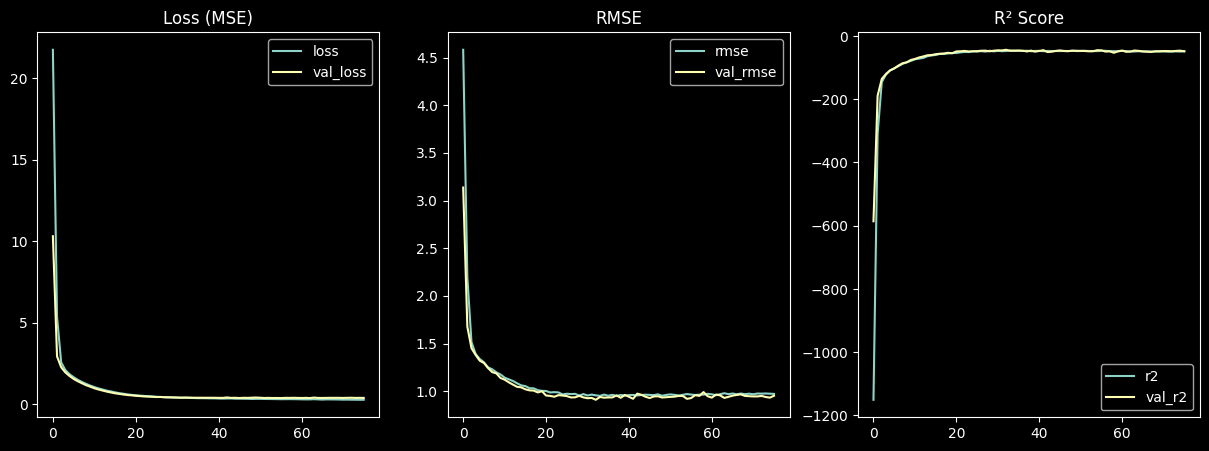

In [31]:
# Loss
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(r.history["loss"], label="loss")
plt.plot(r.history["val_loss"], label="val_loss")
plt.title("Loss (MSE)")
plt.legend()

# RMSE
plt.subplot(1, 3, 2)
plt.plot(r.history["rmse"], label="rmse")
plt.plot(r.history["val_rmse"], label="val_rmse")
plt.title("RMSE")
plt.legend()

# R2
plt.subplot(1, 3, 3)
plt.plot(r.history["r2"], label="r2")
plt.plot(r.history["val_r2"], label="val_r2")
plt.title("R² Score")
plt.legend()
plt.show()


#### 7. Avaliação final

In [32]:
# Predição
y_pred = model.predict(x_test).flatten()

# Cálculo das métricas finais
mse  = mean_squared_error(y_test, y_pred)
rmse_val = sqrt(mse)
r2_val   = r2_score(y_test, y_pred)

print("\n--- RESULTADOS FINAIS ---")
print("mse     = ", mse)
print("rmse    = ", rmse_val)
print("r2      = ", r2_val)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

--- RESULTADOS FINAIS ---
mse     =  0.36998389254306685
rmse    =  0.6082630126376803
r2      =  0.40189519770759585


### 8. Análise dos Resultados

1. Gráficos de Avaliação do Modelo (Loss): A análise das curvas de perda (loss) durante o treino demonstra um comportamento de convergência saudável. Observa-se uma queda acentuada do erro (MSE) nas primeiras épocas, indicando que a rede neural conseguiu extrair rapidamente os padrões principais das características físico-químicas.

    Ao longo do processo, as curvas de treino e validação mantiveram-se próximas e estabilizaram em paralelo, sem que a curva de validação divergisse para valores mais altos. Isto indica que não houve overfitting (sobreajuste) significativo, ou seja, o modelo manteve a capacidade de generalização para dados novos, auxiliado pela técnica de Early Stopping que interrompeu o treino no momento ideal.

2. Métricas de Avaliação do Modelo (R², MSE e RMSE): O modelo obteve um R² (Coeficiente de Determinação) de aproximadamente 0.40. Este valor indica que a rede neural consegue explicar cerca de 41% da variância na qualidade dos vinhos com base nas 11 variáveis químicas fornecidas. Embora pareça um valor moderado, é um resultado consistente para este conjunto de dados (Wine Quality), dado que a atribuição de notas de qualidade a vinhos possui uma componente subjetiva humana que não é totalmente captada apenas pelas medições laboratoriais.

    Em termos práticos, o RMSE (Raiz do Erro Quadrático Médio) de 0.60 revela-se a métrica mais importante: significa que, em média, as previsões do modelo desviam-se da nota real por apenas 0.6 pontos (numa escala de 0 a 10). Considerando a subjetividade do problema, um erro médio inferior a 1 ponto demonstra que a arquitetura implementada é funcional e capaz de realizar estimativas úteis e próximas da realidade.

---

# Fim do código